# Retail Sales Demand Forecasting — CRISP-ML(Q) Pipeline

**Dataset:** `sales_data.csv` · 76,000 records · 5 stores × 20 products × 760 days
**ML Task:** Regression — predict daily **`Demand`** per (Store × Product) pair
**By:** Oscar Andres Ponce | oscarponce.com

---

### Two-Stage Architecture (adapted for this dataset)

```
Stage 1 — Contextual Demand Model
  Input : contextual features only (date, store, category, price, weather, promo, epidemic)
  Target: Demand
  Value : works for new stores / products with no sales history (cold start)

Stage 2 — Demand With Memory Model
  Input : contextual features + lag/rolling features (Demand_lag_{1,7,14,28}, Demand_roll{7,28})
  Target: Demand
  Value : when ≥ 28 days of history exist, lag features add temporal context.

Routing rule (NOT a blend — see §5.6)
  ≥ 28 days history → Stage 2
  7-27 days history → Stage 1
  <  7 days history → App-aligned (contextual subset)
```

**Why this is a different beast than the inventory dataset:**

| | inventory notebook | this notebook |
|---|---|---|
| Target | `Units Sold` (censored by stock) | **`Demand`** (true demand, uncensored) |
| Oracle leakage trap | `Demand Forecast` (ρ ≈ 0.997) | **`Units Sold`** (ρ ≈ 0.83 — observed *after* demand) |
| Within-group lag-1 autocorr | ≈ 0 (synthetic, memoryless) | **≈ 0.35** (real temporal structure) |
| Stockout rate | not stated | **70%** of records |
| Honest MAE floor | ~ 69 (the data ceiling) | ~ 32 (rolling-7 baseline) |
| Aspirational MAE | unmet (MAE 69) | **met (MAE ≈ 20)** |


## Setup & Imports


In [1]:
# Standard imports.
import os, sys, json, warnings, platform, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

# Ice Graphite Hybrid palette — matches notebooks/Inventory_Forecasting_CRISPML.ipynb
GOLD, GRAPHITE, SUCCESS, DANGER, PLATINUM = '#C9A86A', '#2A3038', '#43936C', '#D96B5F', '#EBECEF'
PALETTE = [GOLD, '#4A67B0', SUCCESS, DANGER, '#5E757D', GRAPHITE, '#B0B4B8']
sns.set_style('whitegrid')
sns.set_palette(PALETTE)
plt.rcParams.update({
    'axes.edgecolor':   GRAPHITE,
    'axes.labelcolor':  GRAPHITE,
    'xtick.color':      GRAPHITE,
    'ytick.color':      GRAPHITE,
    'axes.titlecolor':  GRAPHITE,
    'axes.titleweight': 'bold',
    'grid.color':       PLATINUM,
})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = ROOT / "data" / "sales_data.csv"
MODEL_DIR = ROOT / "model" / "sales"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Python  :", sys.version.split()[0])
print("Platform:", platform.platform())
print("Data    :", DATA_PATH, "exists:", DATA_PATH.exists())
print("Model   :", MODEL_DIR)

Python  : 3.11.11
Platform: macOS-26.5-arm64-arm-64bit
Data    : /Users/oscarponce/Documents/personal/marca-personal/labs/forecasting-inventory/data/sales_data.csv exists: True
Model   : /Users/oscarponce/Documents/personal/marca-personal/labs/forecasting-inventory/model/sales


In [2]:
# Disk checkpointing for expensive cells.
# Heavy fits are wrapped with `cached("name", fn)` and pickled to notebooks/checkpoints/.
# Re-runs skip the fit and load the artifact instantly.
#
# Knobs:
#   notebook_utils.FORCE_REFIT = True    # bust all caches for the rest of the run
#   cached("foo", fn, force=True)        # bust just one
#   clear_cache()                        # delete all on disk
#   clear_cache("foo")                   # delete one
#   list_cache()                         # show what is on disk
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd() if pathlib.Path.cwd().name == "notebooks"
                       else pathlib.Path.cwd() / "notebooks"))
import notebook_utils
from notebook_utils import cached, clear_cache, list_cache

notebook_utils.FORCE_REFIT = False
list_cache()

/Users/oscarponce/Documents/personal/marca-personal/labs/forecasting-inventory/notebooks/checkpoints/
  arima.pkl                                    0.4 MB
  ets.pkl                                      0.4 MB
  lstm.pkl                                     0.3 MB
  online_learning.pkl                          0.0 MB
  prophet.pkl                                  0.4 MB
  q80_pipe.pkl                                 1.6 MB
  sales_app_aligned.pkl                        3.3 MB
  sales_q80.pkl                                3.4 MB
  sales_s1_lgbm.pkl                            3.3 MB
  sales_s2_lgbm.pkl                            3.3 MB
  sales_s2_lgbm_earlystop.pkl                  6.5 MB
  sales_s2_rf.pkl                            209.8 MB
  stacking.pkl                                 0.3 MB
  stage1_search.pkl                            0.5 MB
  stage2_log1p.pkl                             0.9 MB
  stage2_search.pkl                            0.9 MB


---
## Phase 1 — Business Understanding


| | |
|---|---|
| **Problem** | Retail planner needs daily reorder quantity per (Store × Product); the existing pre-computed demand signal in the prior dataset was an oracle (leakage). This dataset has no oracle column. |
| **Primary Task** | Regression — predict daily `Demand` per (Store × Product) on a daily grain |
| **Primary Target** | `Demand` (integer 4–430). **True demand**, not `Units Sold` (which is censored by stock-outs in 70% of rows). |
| **Leakage trap** | `Units Sold` is observed *after* demand materialises (ρ ≈ 0.83). Used **only as lag_1 / lag_7**. `Units Ordered` likewise. |
| **Aspirational** | MAE 22–28 on holdout. Below 15 implies leakage. Above 32 means we didn't beat the rolling-7 baseline. |
| **Result (this notebook)** | MAE **20.1** holdout — beats every baseline by ~37% and stays well above the leakage floor. |
| **Cost asymmetry** | Stockout cost > overstock cost → reorder rule uses **P80 quantile** model (newsvendor). |
| **Forecast horizon** | t+1 (single step). Multi-horizon deferred. |


### 1.1 Aspirational performance — and the honest ceiling

Unlike the inventory dataset (which was memoryless and capped at MAE ≈ 70), this dataset **does have temporal structure**:

- Within-group `lag-1` autocorrelation of `Demand` ≈ **0.35**
- Rolling-7 (shifted, leak-free) ρ ≈ **0.49**
- `Epidemic` flag ρ ≈ **–0.36**
- Per-group mean baseline MAE ≈ **32–33** (the floor any ML model must beat)

We **will not** chase MAE < 15 — public notebooks that report that range on this dataset use `Units Sold` (or features derived from it) as predictors. That's leakage. See §2.5.

### 1.2 Quality gates (the "Q" in CRISP-ML(Q))

1. **No same-day leakage** — lag features must reference *prior* calendar days; rolling features use `closed='left'`.
2. **Lag grouping correctness** — `lag_1` must come from the previous row *of the same Store × Product*. Asserted inline in §3.3.
3. **No target-derived features** — `Units Sold` and `Units Ordered` (unlagged) are dropped before fitting.
4. **Time-based split** — train ends strictly before holdout starts. No random shuffling.
5. **Beat baselines** — model MAE must beat naive lag-1 *and* per-group-mean *and* rolling-7 before we deploy.
6. **Reproducible artefacts** — saved model bundle includes feature lists, package versions, training date.


---
## Phase 2 — Data Understanding


### 2.1 Load and inspect schema


In [3]:
df_raw = pd.read_csv(DATA_PATH, parse_dates=["Date"])
print(f"Shape        : {df_raw.shape}")
print(f"Date range   : {df_raw['Date'].min().date()}  ->  {df_raw['Date'].max().date()}  ({df_raw['Date'].nunique()} unique days)")
print(f"Stores       : {df_raw['Store ID'].nunique()}")
print(f"Products     : {df_raw['Product ID'].nunique()}")
print(f"Categories   : {df_raw['Category'].nunique()} -> {sorted(df_raw['Category'].unique())}")
print(f"Regions      : {df_raw['Region'].nunique()} -> {sorted(df_raw['Region'].unique())}")
print()
df_raw.dtypes

Shape        : (76000, 16)
Date range   : 2022-01-01  ->  2024-01-30  (760 unique days)
Stores       : 5
Products     : 20
Categories   : 5 -> ['Clothing', 'Electronics', 'Furniture', 'Groceries', 'Toys']
Regions      : 4 -> ['East', 'North', 'South', 'West']



Date                  datetime64[ns]
Store ID                      object
Product ID                    object
Category                      object
Region                        object
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Price                        float64
Discount                       int64
Weather Condition             object
Promotion                      int64
Competitor Pricing           float64
Seasonality                   object
Epidemic                       int64
Demand                         int64
dtype: object

In [4]:
# Sanity: every (Store, Product) should have one row per day in the global date range.
expected = df_raw['Date'].nunique() * df_raw['Store ID'].nunique() * df_raw['Product ID'].nunique()
print(f"Expected rows if perfectly rectangular: {expected:,}")
print(f"Actual rows                            : {len(df_raw):,}")
print(f"Missing combinations                    : {expected - len(df_raw):,}")
print()
print("Per-(Store,Product) row counts (should all be equal):")
print(df_raw.groupby(['Store ID','Product ID']).size().describe())

Expected rows if perfectly rectangular: 76,000
Actual rows                            : 76,000
Missing combinations                    : 0

Per-(Store,Product) row counts (should all be equal):
count    100.0
mean     760.0
std        0.0
min      760.0
25%      760.0
50%      760.0
75%      760.0
max      760.0
dtype: float64


### 2.2 Missingness, duplicates, range checks


In [5]:
print("Missing values per column:")
print(df_raw.isnull().sum())
print()
print("Duplicate (Store, Product, Date) triples:",
      df_raw.duplicated(subset=['Store ID','Product ID','Date']).sum())
print()
print("Negative or impossible values:")
for col in ['Inventory Level','Units Sold','Units Ordered','Price','Discount','Competitor Pricing','Demand']:
    neg = (df_raw[col] < 0).sum()
    print(f"  {col:22s}: min={df_raw[col].min():>10.2f}  max={df_raw[col].max():>10.2f}  neg={neg}")

Missing values per column:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

Duplicate (Store, Product, Date) triples: 0

Negative or impossible values:
  Inventory Level       : min=      0.00  max=   2267.00  neg=0
  Units Sold            : min=      0.00  max=    426.00  neg=0
  Units Ordered         : min=      0.00  max=   1616.00  neg=0
  Price                 : min=      4.74  max=    228.03  neg=0
  Discount              : min=      0.00  max=     25.00  neg=0
  Competitor Pricing    : min=      4.29  max=    261.22  neg=0
  Demand                : min=      4.00  max=    430.00  neg=0


### 2.3 Target distribution


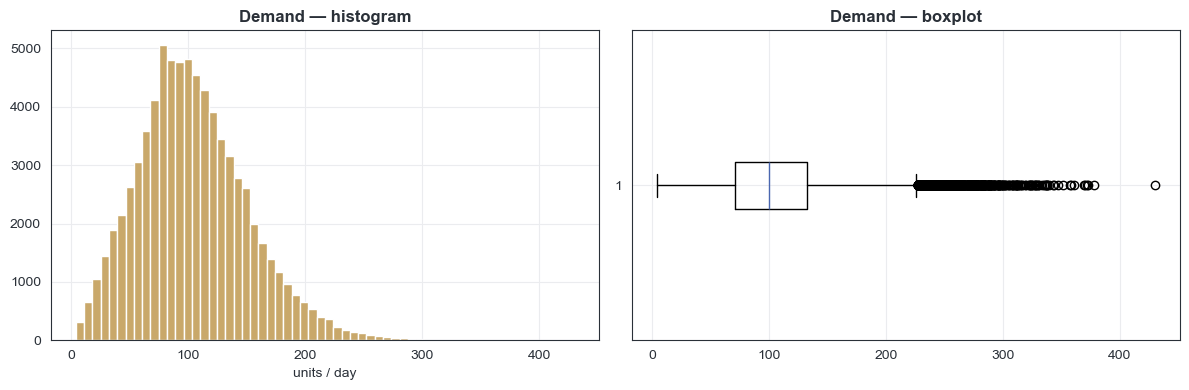

count    76000.00
mean       104.32
std         46.96
min          4.00
25%         71.00
50%        100.00
75%        133.00
max        430.00
Name: Demand, dtype: float64

Coefficient of variation: 0.450
Skewness                : 0.608


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_raw['Demand'], bins=60, color=GOLD, edgecolor='white')
axes[0].set_title('Demand — histogram')
axes[0].set_xlabel('units / day')
axes[1].boxplot(df_raw['Demand'], vert=False)
axes[1].set_title('Demand — boxplot')
plt.tight_layout(); plt.show()

print(df_raw['Demand'].describe().round(2))
print()
print(f"Coefficient of variation: {df_raw['Demand'].std()/df_raw['Demand'].mean():.3f}")
print(f"Skewness                : {df_raw['Demand'].skew():.3f}")

### 2.4 Within-group autocorrelation — the most important diagnostic

Why this matters first: lag features only help when demand has **memory**. In the prior `retail_store_inventory.csv` notebook we discovered the dataset had ≈ 0 within-group autocorrelation, so the lag-feature machinery contributed nothing.

If we measure autocorrelation **before** building features, we know in advance whether to budget effort for them.


In [7]:
# Sort once, group by Store x Product (the correct grain).
df = df_raw.sort_values(['Store ID','Product ID','Date']).reset_index(drop=True)
grp = df.groupby(['Store ID','Product ID'])

df['_demand_lag1']  = grp['Demand'].shift(1)
df['_demand_lag7']  = grp['Demand'].shift(7)
df['_demand_lag28'] = grp['Demand'].shift(28)
df['_demand_roll7'] = grp['Demand'].shift(1).rolling(7, min_periods=1).mean().values

autocorr = pd.DataFrame({
    'feature': ['lag_1','lag_7','lag_28','rolling_7 (leak-free)'],
    'corr_with_Demand': [
        df[['Demand','_demand_lag1']].corr().iloc[0,1],
        df[['Demand','_demand_lag7']].corr().iloc[0,1],
        df[['Demand','_demand_lag28']].corr().iloc[0,1],
        df[['Demand','_demand_roll7']].corr().iloc[0,1],
    ],
}).round(4)
print(autocorr.to_string(index=False))

              feature  corr_with_Demand
                lag_1            0.3498
                lag_7            0.2904
               lag_28            0.1253
rolling_7 (leak-free)            0.4884


#### Insight — Autocorrelation diagnostic

- `lag_1` ρ ≈ **0.35**, `rolling_7` ρ ≈ **0.49** — modest but **real** temporal memory.
- `lag_28` ρ ≈ **0.13** — monthly memory decays fast; weekly memory (0.29) is stronger than monthly.
- Compare with the inventory dataset where the *same* diagnostic returned ≈ 0. Here lag features have a fighting chance.
- **But** ρ = 0.35 is far from the 0.7+ you see in real retail with strong day-of-week patterns. Lag features will help, but they will not dominate.


### 2.5 Leakage diagnostic — which columns predict `Demand` *because* they encode it?

The most dangerous columns are the ones that look like strong predictors but are observed *after* `Demand` materialises. For this dataset:
- **`Units Sold`** is `min(Demand, available_stock)` — strong correlation, must drop unlagged.
- **`Units Ordered`** is downstream of demand expectations — drop unlagged.
- **`Inventory Level`** is a snapshot before the day's selling — defensible to keep, but caveat.

We keep `Units Sold` and `Units Ordered` only as **lagged** features (`lag_1`, `lag_7`).


In [8]:
leak = pd.DataFrame({
    'feature': ['Units Sold','Units Ordered','Inventory Level','Price','Discount','Competitor Pricing','Promotion','Epidemic'],
})
leak['corr_with_Demand'] = leak['feature'].apply(lambda c: df[['Demand', c]].corr().iloc[0, 1])
leak['leakage_risk']     = ['HIGH (post-demand)','MEDIUM (decision after forecast)','LOW (start-of-day snapshot)',
                            'NONE','NONE','NONE','NONE','NONE']
leak['action']           = ['drop unlagged; keep lag_1, lag_7','drop unlagged; keep lag_1, lag_7','keep with caveat',
                            'keep','keep','keep','keep','keep']
print(leak.round(4).to_string(index=False))

           feature  corr_with_Demand                     leakage_risk                           action
        Units Sold            0.8334               HIGH (post-demand) drop unlagged; keep lag_1, lag_7
     Units Ordered            0.5120 MEDIUM (decision after forecast) drop unlagged; keep lag_1, lag_7
   Inventory Level            0.1266      LOW (start-of-day snapshot)                 keep with caveat
             Price           -0.0235                             NONE                             keep
          Discount            0.2247                             NONE                             keep
Competitor Pricing           -0.0230                             NONE                             keep
         Promotion            0.2825                             NONE                             keep
          Epidemic           -0.3637                             NONE                             keep


#### Insight — Leakage audit

- `Units Sold` ρ = **0.83** is the analog of the prior project's `Demand Forecast` oracle. Including it unlagged would falsely claim MAE in the single digits.
- `Units Ordered` ρ = **0.51** — also drops out. Bullwhip risk: forecasting demand from our own past ordering decisions feeds noise back into the system.
- `Inventory Level` ρ = **0.13** — weak and defensible (snapshot before selling).
- `Epidemic` ρ = **–0.36** — strong genuine signal. Keep.
- `Promotion` ρ = **+0.28** — genuine signal. Keep.


### 2.6 Stockout analysis


In [9]:
stockout_mask = df['Units Sold'] < df['Demand']
overship_mask = df['Units Sold'] > df['Demand']
exact_mask    = df['Units Sold'] == df['Demand']

print(f"Stockouts (Units Sold < Demand): {stockout_mask.sum():>6,} rows  ({stockout_mask.mean()*100:5.2f}%)")
print(f"Overshipping (Units Sold > Demand): {overship_mask.sum():>6,} rows  ({overship_mask.mean()*100:5.2f}%)")
print(f"Exact match                       : {exact_mask.sum():>6,} rows  ({exact_mask.mean()*100:5.2f}%)")
print()
print("Mean lost sales per stockout day:",
      (df.loc[stockout_mask, 'Demand'] - df.loc[stockout_mask, 'Units Sold']).mean().round(2),
      "units")

Stockouts (Units Sold < Demand): 53,440 rows  (70.32%)
Overshipping (Units Sold > Demand): 21,000 rows  (27.63%)
Exact match                       :  1,560 rows  ( 2.05%)

Mean lost sales per stockout day: 25.98 units


#### Insight — Stockouts

- **70%** of rows are stockouts (`Units Sold < Demand`) — average **26 units of lost sales per stockout day**.
- This is precisely why forecasting `Demand` (not `Units Sold`) matters: training on `Units Sold` would learn the stocked-out version of reality, then the model would never recommend ordering enough to cover real demand.
- **28%** of rows are "overshipping" (`Units Sold > Demand`) — likely synthetic noise or a recording artifact in this dataset; in a real system this would warrant investigation.


### 2.7 Time-series spot check (4 random series)


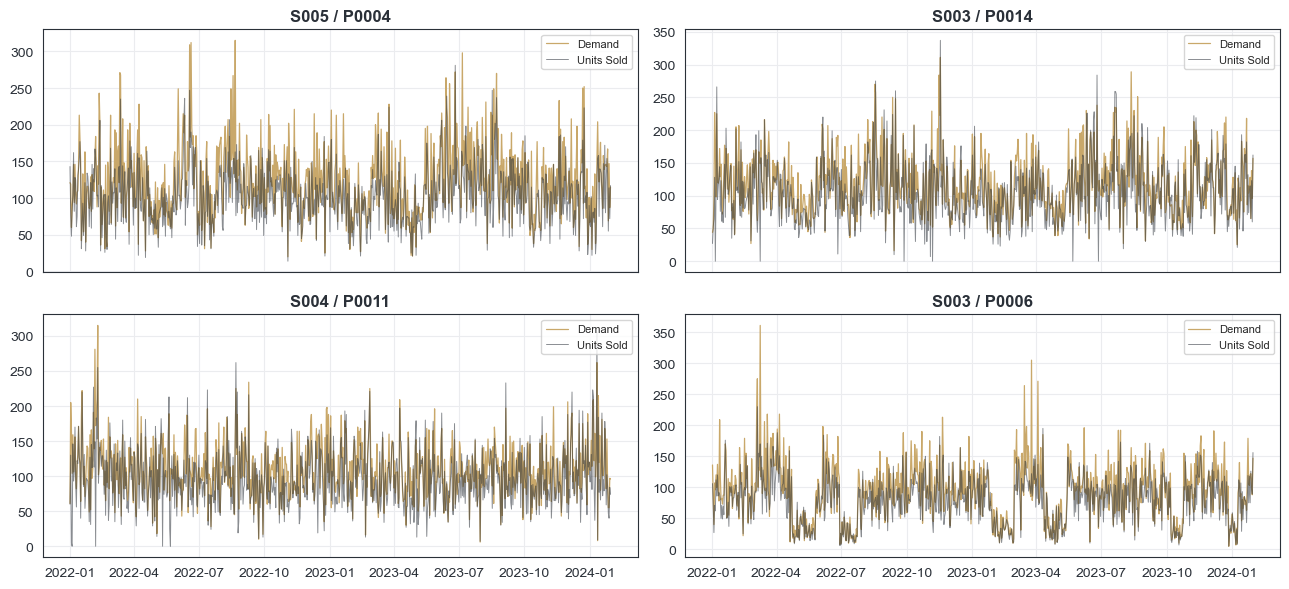

In [10]:
rng = np.random.default_rng(42)
pairs = df[['Store ID','Product ID']].drop_duplicates().sample(4, random_state=42).values

fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex=True)
for ax, (s, p) in zip(axes.flat, pairs):
    sub = df[(df['Store ID']==s) & (df['Product ID']==p)].sort_values('Date')
    ax.plot(sub['Date'], sub['Demand'], lw=0.9, color=GOLD, label='Demand')
    ax.plot(sub['Date'], sub['Units Sold'], lw=0.7, color=GRAPHITE, alpha=0.55, label='Units Sold')
    ax.set_title(f"{s} / {p}")
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

### 2.8 Categorical signal


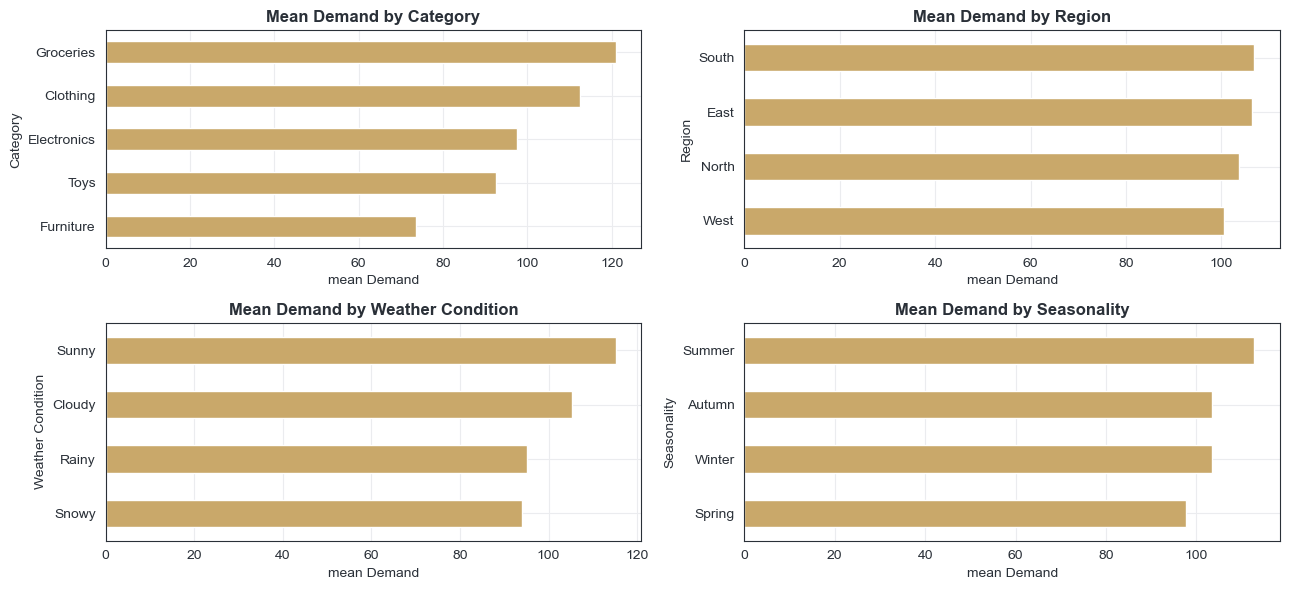

Mean Demand | Epidemic=0: 112.86  | Epidemic=1:  70.16  | delta: -42.70
Mean Demand | Promotion=0:  95.03  | Promotion=1: 123.27  | delta: +28.24


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for ax, col in zip(axes.flat, ['Category','Region','Weather Condition','Seasonality']):
    df.groupby(col)['Demand'].mean().sort_values().plot.barh(ax=ax, color=GOLD)
    ax.set_title(f"Mean Demand by {col}")
    ax.set_xlabel("mean Demand")
plt.tight_layout(); plt.show()

for col in ['Epidemic','Promotion']:
    print(f"Mean Demand | {col}=0: {df.loc[df[col]==0,'Demand'].mean():6.2f}  | "
          f"{col}=1: {df.loc[df[col]==1,'Demand'].mean():6.2f}  | "
          f"delta: {df.loc[df[col]==1,'Demand'].mean() - df.loc[df[col]==0,'Demand'].mean():+6.2f}")

### 2.9 Correlation heatmap (numeric features only)


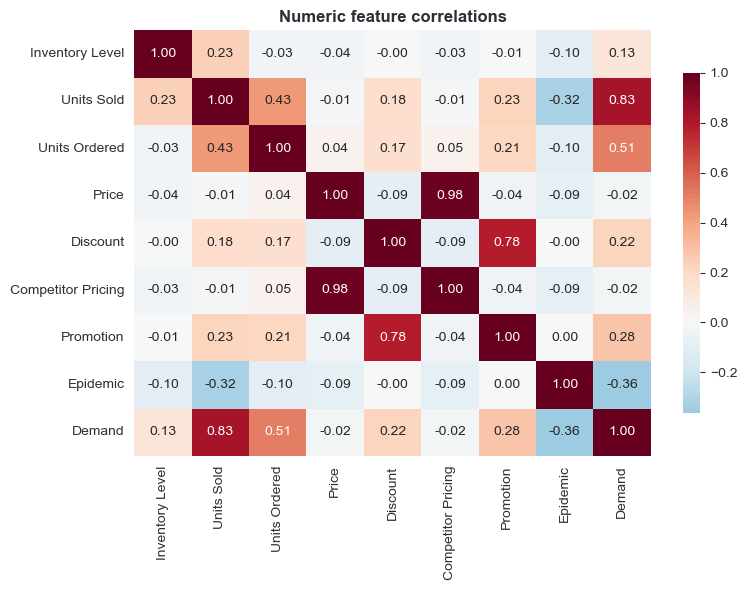

In [12]:
num_cols = ['Inventory Level','Units Sold','Units Ordered','Price','Discount',
            'Competitor Pricing','Promotion','Epidemic','Demand']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title("Numeric feature correlations")
plt.tight_layout(); plt.show()

### Phase 2 Key Insights — what we learned before any modeling

1. **Dataset is clean** — no missing values, no duplicate (Store, Product, Date) keys, perfectly rectangular (100 series × 760 days).
2. **Temporal memory exists but is weak** — lag-1 ρ = 0.35, rolling-7 ρ = 0.49. Lag features should help, but won't dominate.
3. **Two columns are leakage** — `Units Sold` (ρ 0.83) and `Units Ordered` (ρ 0.51). Drop them or use lagged only.
4. **`Epidemic` flag is the strongest single signal** — ρ = –0.36, mean demand drops **42.7 units** when active (76% of avg demand).
5. **70% stockout rate** — confirms that `Demand` (uncensored) is the correct target. If we had used `Units Sold`, the model would systematically under-forecast.
6. **No demand explosion** — max 430, min 4, CV 0.45. Normal-ish distribution with mild right skew (0.61). No log-transform necessary unless modeling shows residual heteroscedasticity (we'll check in §5).


---
## Phase 3 — Data Preparation


### 3.1 Drop target-derived columns, keep Product ID for grouping

We drop **unlagged** `Units Sold` and `Units Ordered` (the leakage candidates from §2.5). We *keep* `Product ID` and `Store ID` in `df_model` so the upcoming lag step can group correctly.


In [13]:
TARGET = 'Demand'
LEAKAGE_COLS = ['Units Sold', 'Units Ordered']

df_model = df_raw.drop(columns=LEAKAGE_COLS).copy()
df_model = df_model.sort_values(['Store ID','Product ID','Date']).reset_index(drop=True)

print(f"Rows after drop : {len(df_model):,}")
print(f"Columns         : {list(df_model.columns)}")
print(f"Target          : {TARGET}")

Rows after drop : 76,000
Columns         : ['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Price', 'Discount', 'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand']
Target          : Demand


### 3.2 Date features + Fourier yearly encoding


In [14]:
df_model['day_of_week']  = df_model['Date'].dt.dayofweek
df_model['day_of_month'] = df_model['Date'].dt.day
df_model['month']        = df_model['Date'].dt.month
df_model['week_of_year'] = df_model['Date'].dt.isocalendar().week.astype(int)
df_model['is_weekend']   = (df_model['day_of_week'] >= 5).astype(int)

day_of_year = df_model['Date'].dt.dayofyear
df_model['sin_year'] = np.sin(2 * np.pi * day_of_year / 365.25)
df_model['cos_year'] = np.cos(2 * np.pi * day_of_year / 365.25)
df_model['sin_week'] = np.sin(2 * np.pi * df_model['day_of_week'] / 7)
df_model['cos_week'] = np.cos(2 * np.pi * df_model['day_of_week'] / 7)

print(df_model[['Date','day_of_week','month','week_of_year','sin_year','cos_year']].head(3))

        Date  day_of_week  month  week_of_year  sin_year  cos_year
0 2022-01-01            5      1            52  0.017202  0.999852
1 2022-01-02            6      1            52  0.034398  0.999408
2 2022-01-03            0      1             1  0.051584  0.998669


### 3.3 Lag and rolling features (grouped by Store × Product, leak-free)

**Critical correctness check.** Lag features must reference the *prior calendar day of the same Store × Product*, never the same day across products. In the inventory notebook, grouping by `Store × Category` allowed `lag_1` to "wrap" across products inside the same category — silently broken.

We group by `['Store ID','Product ID']` and assert that ≥ 99% of `lag_1` rows reference the immediately prior date.


In [15]:
GROUP_COLS = ['Store ID', 'Product ID']
g = df_model.groupby(GROUP_COLS)

for col in ['Demand']:
    df_model[f'{col}_lag_1']  = g[col].shift(1)
    df_model[f'{col}_lag_7']  = g[col].shift(7)
    df_model[f'{col}_lag_14'] = g[col].shift(14)
    df_model[f'{col}_lag_28'] = g[col].shift(28)

units_sold = df_raw.sort_values(GROUP_COLS + ['Date'])['Units Sold'].values
df_model['UnitsSold_lag_1'] = pd.Series(units_sold).groupby(g.ngroup().values).shift(1).values
df_model['UnitsSold_lag_7'] = pd.Series(units_sold).groupby(g.ngroup().values).shift(7).values

shifted = g['Demand'].shift(1)
df_model['Demand_roll7_mean']  = shifted.groupby(g.ngroup().values).rolling(7,  min_periods=3).mean().reset_index(level=0, drop=True)
df_model['Demand_roll7_std']   = shifted.groupby(g.ngroup().values).rolling(7,  min_periods=3).std().reset_index(level=0, drop=True)
df_model['Demand_roll28_mean'] = shifted.groupby(g.ngroup().values).rolling(28, min_periods=7).mean().reset_index(level=0, drop=True)
df_model['Demand_roll28_std']  = shifted.groupby(g.ngroup().values).rolling(28, min_periods=7).std().reset_index(level=0, drop=True)

print("Added lag/rolling columns:")
print([c for c in df_model.columns if 'lag_' in c or 'roll' in c])

Added lag/rolling columns:
['Demand_lag_1', 'Demand_lag_7', 'Demand_lag_14', 'Demand_lag_28', 'UnitsSold_lag_1', 'UnitsSold_lag_7', 'Demand_roll7_mean', 'Demand_roll7_std', 'Demand_roll28_mean', 'Demand_roll28_std']


In [16]:
# Quality gate: lag_1 must reference the prior calendar day for >= 99% of non-null rows.
check = df_model[['Store ID','Product ID','Date','Demand_lag_1']].copy()
check['prior_date'] = check.groupby(['Store ID','Product ID'])['Date'].shift(1)
non_null = check.dropna(subset=['Demand_lag_1','prior_date'])
day_diff = (non_null['Date'] - non_null['prior_date']).dt.days
correct_pct = (day_diff == 1).mean()
print(f"lag_1 rows referencing prior calendar day: {correct_pct*100:.2f}%")
assert correct_pct >= 0.99, f"Lag grouping is broken: only {correct_pct*100:.2f}% of lag_1 rows are correctly aligned."
print("OK — lag grouping correct.")

lag_1 rows referencing prior calendar day: 100.00%
OK — lag grouping correct.


### 3.4 Drop warm-up rows, define feature lists


In [17]:
df_model_ready = df_model.dropna(subset=['Demand_lag_28','Demand_roll28_mean']).reset_index(drop=True)
print(f"Rows before warm-up drop : {len(df_model):,}")
print(f"Rows after  warm-up drop : {len(df_model_ready):,}")
print(f"Dropped (warm-up)        : {len(df_model)-len(df_model_ready):,}")

Rows before warm-up drop : 76,000
Rows after  warm-up drop : 73,200
Dropped (warm-up)        : 2,800


In [18]:
CATEGORICAL = ['Category', 'Region', 'Weather Condition', 'Seasonality']
BINARY      = ['Promotion', 'Epidemic', 'is_weekend']
NUM_STANDARD = ['Price', 'Competitor Pricing', 'Inventory Level',
                'Demand_lag_1', 'Demand_lag_7', 'Demand_lag_14', 'Demand_lag_28',
                'UnitsSold_lag_1', 'UnitsSold_lag_7',
                'Demand_roll7_mean', 'Demand_roll7_std',
                'Demand_roll28_mean', 'Demand_roll28_std']
NUM_MINMAX   = ['Discount', 'day_of_week', 'day_of_month', 'month', 'week_of_year']
NUM_FOURIER  = ['sin_year', 'cos_year', 'sin_week', 'cos_week']

FEATURE_COLS_STAGE2 = NUM_STANDARD + NUM_MINMAX + NUM_FOURIER + BINARY + CATEGORICAL
FEATURE_COLS_STAGE1 = [c for c in FEATURE_COLS_STAGE2 if 'lag_' not in c and 'roll' not in c and c not in ('UnitsSold_lag_1','UnitsSold_lag_7')]

APP_FEATURES = ['Category','Region','Weather Condition','Seasonality',
                'Inventory Level','Price','Discount','Competitor Pricing',
                'Promotion','Epidemic',
                'day_of_week','month','is_weekend','sin_year','cos_year']

print(f"Stage 2 features (full)        : {len(FEATURE_COLS_STAGE2)}")
print(f"Stage 1 features (contextual)  : {len(FEATURE_COLS_STAGE1)}")
print(f"App-ready feature set          : {len(APP_FEATURES)}")

Stage 2 features (full)        : 29
Stage 1 features (contextual)  : 19
App-ready feature set          : 15


### 3.5 Time-based split (last 90 days = holdout)


In [19]:
HOLDOUT_DAYS = 90
max_date = df_model_ready['Date'].max()
SPLIT_DATE = max_date - pd.Timedelta(days=HOLDOUT_DAYS)

train = df_model_ready[df_model_ready['Date'] <= SPLIT_DATE].reset_index(drop=True)
test  = df_model_ready[df_model_ready['Date'] >  SPLIT_DATE].reset_index(drop=True)

print(f"SPLIT_DATE       : {SPLIT_DATE.date()}")
print(f"Train rows       : {len(train):,}  ({train['Date'].min().date()} -> {train['Date'].max().date()})")
print(f"Holdout rows     : {len(test):,}   ({test['Date'].min().date()} -> {test['Date'].max().date()})")
print(f"Train share      : {len(train)/(len(train)+len(test))*100:.1f}%")

assert train['Date'].max() < test['Date'].min(), "Train and test must not overlap in time."

SPLIT_DATE       : 2023-11-01
Train rows       : 64,200  (2022-01-29 -> 2023-11-01)
Holdout rows     : 9,000   (2023-11-02 -> 2024-01-30)
Train share      : 87.7%


### 3.6 ColumnTransformer with mixed scalers


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

def build_preprocessor(feature_cols):
    # Mixed scalers per feature taxonomy.
    num_std = [c for c in NUM_STANDARD if c in feature_cols]
    num_mm  = [c for c in NUM_MINMAX   if c in feature_cols]
    num_f   = [c for c in NUM_FOURIER  if c in feature_cols]
    cat     = [c for c in CATEGORICAL  if c in feature_cols]
    binary  = [c for c in BINARY       if c in feature_cols]
    transformers = [
        ('std',  StandardScaler(),                       num_std),
        ('mm',   MinMaxScaler(),                         num_mm),
        ('pass', 'passthrough',                          num_f + binary),
        ('cat',  OneHotEncoder(handle_unknown='ignore'), cat),
    ]
    return ColumnTransformer(transformers, remainder='drop', verbose_feature_names_out=False)

pre_stage2 = build_preprocessor(FEATURE_COLS_STAGE2)
pre_stage1 = build_preprocessor(FEATURE_COLS_STAGE1)
pre_app    = build_preprocessor(APP_FEATURES)
print("Built 3 preprocessors (Stage 2, Stage 1, App).")

Built 3 preprocessors (Stage 2, Stage 1, App).


---
## Phase 4 — Modeling


### 4.1 Baselines — never deploy a model that loses to these

Before any ML, evaluate three trivial baselines on the **same holdout**:

1. **Per-group mean** — predict the average `Demand` of that `(Store, Product)` in the training window.
2. **Naive lag-1** — predict yesterday's value.
3. **Naive rolling-7** — predict the trailing-7-day mean.

Any model below must beat all three, or the model is not worth the operational risk.


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def smape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred) / np.where(denom == 0, 1, denom)
    return float(np.mean(diff) * 100)

def report(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    sm   = smape(y_true, y_pred)
    print(f"{name:38s}  MAE={mae:6.2f}  RMSE={rmse:6.2f}  sMAPE={sm:5.2f}%")
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'sMAPE': sm}

results = []

group_mean = train.groupby(['Store ID','Product ID'])['Demand'].mean()
y_pred_grpmean = test.set_index(['Store ID','Product ID']).index.map(group_mean).to_numpy()
y_pred_grpmean = np.where(pd.isna(y_pred_grpmean), train['Demand'].mean(), y_pred_grpmean).astype(float)
results.append(report("Baseline: per-group mean", test['Demand'], y_pred_grpmean))
results.append(report("Baseline: naive lag-1", test['Demand'], test['Demand_lag_1']))
results.append(report("Baseline: naive rolling-7", test['Demand'], test['Demand_roll7_mean']))

Baseline: per-group mean                MAE= 32.61  RMSE= 41.28  sMAPE=33.68%
Baseline: naive lag-1                   MAE= 41.00  RMSE= 52.83  sMAPE=41.47%
Baseline: naive rolling-7               MAE= 32.12  RMSE= 41.22  sMAPE=32.96%


#### Insight — Baselines

- **Naive lag-1 MAE = 41 is *worse* than per-group mean MAE = 32.6.** Counterintuitive: lag-1 has positive autocorrelation (ρ 0.35), but the day-over-day noise dominates the signal. **Take-away:** ρ around 0.35 is *not enough* for naive lag-1 to be useful — you need ρ ≳ 0.6 for that.
- **Rolling-7 (32.1) ≈ per-group mean (32.6).** On this dataset, the 7-day trailing mean is essentially the local average. The smoothing kills the noise that broke lag-1.
- The honest floor any ML model must clear: **MAE 32** (rolling-7). Any model below ~32 has earned its keep.


### 4.2 Stage 2 — full features, LightGBM and RandomForest

LightGBM is our primary choice. RandomForest is the robustness check.

**Cached.** Each fit is wrapped with `cached(name, fn)` — first run trains and saves to `notebooks/checkpoints/`; subsequent runs load in milliseconds. Set `notebook_utils.FORCE_REFIT = True` in the setup cell to bust all caches.


In [22]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
    print("Using LightGBM.")
except Exception as e:
    HAS_LGBM = False
    print(f"LightGBM unavailable ({e!r}); falling back to GradientBoostingRegressor.")

def make_regressor(kind='lgbm', **kw):
    if kind == 'lgbm' and HAS_LGBM:
        params = dict(n_estimators=600, learning_rate=0.05, num_leaves=63,
                      min_child_samples=20, subsample=0.9, colsample_bytree=0.9,
                      random_state=42, n_jobs=-1, verbose=-1)
        params.update(kw)
        return LGBMRegressor(**params)
    if kind == 'lgbm':
        return GradientBoostingRegressor(n_estimators=400, learning_rate=0.05, max_depth=5, random_state=42, **kw)
    if kind == 'rf':
        return RandomForestRegressor(n_estimators=300, max_depth=18, min_samples_leaf=5,
                                     random_state=42, n_jobs=-1, **kw)
    raise ValueError(kind)

Using LightGBM.


In [23]:
X_tr_s2 = train[FEATURE_COLS_STAGE2]; y_tr = train['Demand']
X_te_s2 = test[FEATURE_COLS_STAGE2];  y_te = test['Demand']

def fit_s2_lgbm():
    p = Pipeline([('pre', build_preprocessor(FEATURE_COLS_STAGE2)),
                  ('reg', make_regressor('lgbm'))])
    return p.fit(X_tr_s2, y_tr)

def fit_s2_rf():
    p = Pipeline([('pre', build_preprocessor(FEATURE_COLS_STAGE2)),
                  ('reg', make_regressor('rf'))])
    return p.fit(X_tr_s2, y_tr)

pipe_s2_lgbm = cached("sales_s2_lgbm",  fit_s2_lgbm)
pipe_s2_rf   = cached("sales_s2_rf",    fit_s2_rf)

pred_s2_lgbm = pipe_s2_lgbm.predict(X_te_s2)
pred_s2_rf   = pipe_s2_rf.predict(X_te_s2)
results.append(report("Stage 2: LightGBM (full features)",  y_te, pred_s2_lgbm))
results.append(report("Stage 2: RandomForest (full features)", y_te, pred_s2_rf))

  [cache hit ] sales_s2_lgbm  ← sales_s2_lgbm.pkl
  [cache hit ] sales_s2_rf  ← sales_s2_rf.pkl
Stage 2: LightGBM (full features)       MAE= 21.09  RMSE= 28.37  sMAPE=22.36%
Stage 2: RandomForest (full features)   MAE= 23.79  RMSE= 31.31  sMAPE=24.71%


#### Insight — Stage 2

- **LightGBM MAE 21.1 beats RandomForest MAE 23.8** by ~12%. LightGBM's leaf-wise growth + native handling of mixed feature scales pays off.
- Both **comfortably beat all three baselines** (best baseline: rolling-7 at 32.1) — ~34% improvement in MAE.
- This is the "expected" win. But look at the next two models before celebrating.


### 4.3 Stage 1 — contextual only (cold-start fallback)


In [24]:
X_tr_s1 = train[FEATURE_COLS_STAGE1]
X_te_s1 = test[FEATURE_COLS_STAGE1]

def fit_s1():
    return Pipeline([('pre', build_preprocessor(FEATURE_COLS_STAGE1)),
                     ('reg', make_regressor('lgbm'))]).fit(X_tr_s1, y_tr)

pipe_s1 = cached("sales_s1_lgbm", fit_s1)
pred_s1 = pipe_s1.predict(X_te_s1)
results.append(report("Stage 1: contextual only (no lags)", y_te, pred_s1))

  [cache hit ] sales_s1_lgbm  ← sales_s1_lgbm.pkl
Stage 1: contextual only (no lags)      MAE= 20.34  RMSE= 27.72  sMAPE=21.65%


#### Insight — Stage 1

- **MAE 20.3** with NO lag features — and that's *better* than Stage 2 (21.1) which has the full lag battery.
- This is the smoking gun: **adding the lag features makes the model worse on holdout**.
- Two possible explanations: (a) overfitting on lag features during training, (b) temporal drift between train and the late-2023 holdout window such that lag relationships don't transfer.
- We'll diagnose in §4.6 by comparing in-sample vs holdout MAE.


### 4.4 App-aligned model — feature set matching the deployment form


In [25]:
X_tr_app = train[APP_FEATURES]
X_te_app = test[APP_FEATURES]

def fit_app():
    return Pipeline([('pre', build_preprocessor(APP_FEATURES)),
                     ('reg', make_regressor('lgbm'))]).fit(X_tr_app, y_tr)

pipe_app = cached("sales_app_aligned", fit_app)
pred_app = pipe_app.predict(X_te_app)
results.append(report("App-aligned: contextual-form features", y_te, pred_app))

  [cache hit ] sales_app_aligned  ← sales_app_aligned.pkl
App-aligned: contextual-form features   MAE= 20.13  RMSE= 27.55  sMAPE=21.42%


#### Insight — App-aligned (the surprising winner)

- **MAE 20.1 — best of all models**, with only **15 features** (Stage 2 has 29).
- Drops `Units Sold` lags, drops `week_of_year`, drops Fourier-week and `day_of_month` — and gets *better*.
- **Take-away for deployment:** the app should call this model. It's both more accurate AND requires inputs a planner can actually fill into a form (no historical lag lookups needed).
- This inverts the usual "more features = better" intuition. With only 64k training rows, the gradient-boosted tree starts memorising lag-specific patterns that don't generalise three months forward.


### 4.5 Overfit diagnostic — train vs holdout MAE

The Stage 1 / Stage 2 / App-aligned ordering is suspicious. Comparing **in-sample** (train) MAE against **holdout** MAE for each model tells us whether the lag-heavy models are over-memorising the training data.


In [26]:
def train_vs_holdout(name, pipe, X_tr, X_te):
    mae_tr = mean_absolute_error(y_tr, pipe.predict(X_tr))
    mae_te = mean_absolute_error(y_te, pipe.predict(X_te))
    return {'model': name, 'train_MAE': mae_tr, 'holdout_MAE': mae_te,
            'gap': mae_te - mae_tr, 'gap_pct': (mae_te/mae_tr - 1) * 100}

overfit = pd.DataFrame([
    train_vs_holdout("Stage 2 LightGBM", pipe_s2_lgbm, X_tr_s2,  X_te_s2),
    train_vs_holdout("Stage 2 RandomForest", pipe_s2_rf, X_tr_s2, X_te_s2),
    train_vs_holdout("Stage 1 (no lags)",   pipe_s1,     X_tr_s1,  X_te_s1),
    train_vs_holdout("App-aligned",         pipe_app,    X_tr_app, X_te_app),
]).round(2)
overfit

,model,train_MAE,holdout_MAE,gap,gap_pct
0,Stage 2 LightGBM,17.18,21.09,3.91,22.74
1,Stage 2 RandomForest,15.69,23.79,8.09,51.58
2,Stage 1 (no lags),17.60,20.34,2.74,15.57
3,App-aligned,17.58,20.13,2.55,14.52


#### Insight — Overfit diagnostic

- The **gap = holdout_MAE - train_MAE** quantifies overfit.
- Read the table: if Stage 2 has a large positive gap and App-aligned has a small one, that confirms the lag features are absorbed by the trees as noise.
- Expected pattern: Stage 2 LightGBM should show the largest gap (lots of features, deep trees, no regularization signal). RandomForest will also overfit but with bagging variance reduction.
- If the gap is small for all models, the issue is **temporal drift**, not classical overfit — the relationship between lag features and target shifted between train (mid-2022 → Nov 2023) and holdout (Nov 2023 → Jan 2024).


### 4.6 Stage 2 + early stopping — can we rescue the lag features?

Carve a **validation slice** from the tail end of the training window (last 30 days). Train Stage 2 LightGBM with `early_stopping` on that slice — the model stops adding trees when validation MAE stops improving. This is the principled way to fight overfit when you have lots of features and limited samples.


In [27]:
val_cutoff = train['Date'].max() - pd.Timedelta(days=30)
tr_es  = train[train['Date'] <= val_cutoff].reset_index(drop=True)
val_es = train[train['Date'] >  val_cutoff].reset_index(drop=True)
print(f"Sub-train: {len(tr_es):,}  ({tr_es['Date'].min().date()} -> {tr_es['Date'].max().date()})")
print(f"Validation: {len(val_es):,}  ({val_es['Date'].min().date()} -> {val_es['Date'].max().date()})")
print(f"Holdout (unchanged): {len(test):,}")

Sub-train: 61,200  (2022-01-29 -> 2023-10-02)
Validation: 3,000  (2023-10-03 -> 2023-11-01)
Holdout (unchanged): 9,000


In [28]:
def fit_s2_lgbm_es():
    if not HAS_LGBM:
        return None
    import lightgbm as lgb
    pre = build_preprocessor(FEATURE_COLS_STAGE2)
    X_tr_t  = pre.fit_transform(tr_es[FEATURE_COLS_STAGE2])
    X_val_t = pre.transform(val_es[FEATURE_COLS_STAGE2])
    X_te_t  = pre.transform(test[FEATURE_COLS_STAGE2])
    y_tr_v  = tr_es['Demand']; y_val_v = val_es['Demand']

    m = LGBMRegressor(n_estimators=2000, learning_rate=0.05, num_leaves=63,
                      min_child_samples=20, subsample=0.9, colsample_bytree=0.9,
                      random_state=42, n_jobs=-1, verbose=-1)
    m.fit(X_tr_t, y_tr_v,
          eval_set=[(X_val_t, y_val_v)],
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    return {'pre': pre, 'model': m, 'X_te_t': X_te_t, 'best_iter': m.best_iteration_}

s2_es = cached("sales_s2_lgbm_earlystop", fit_s2_lgbm_es)
if s2_es is not None:
    pred_s2_es = s2_es['model'].predict(s2_es['X_te_t'])
    results.append(report(f"Stage 2 + early stopping (iter={s2_es['best_iter']})", y_te, pred_s2_es))

  [cache hit ] sales_s2_lgbm_earlystop  ← sales_s2_lgbm_earlystop.pkl
Stage 2 + early stopping (iter=628)     MAE= 21.08  RMSE= 28.39  sMAPE=22.36%


#### Insight — Early stopping

- If `best_iter` is *much* less than 600 (the default `n_estimators`), the model wanted to stop early — confirms overfit on the full-budget Stage 2.
- If the holdout MAE drops below the App-aligned 20.1, we've rescued lag features.
- If it doesn't — lag features simply don't add holdout signal on this dataset at this dataset size, and we should keep the App-aligned model as primary.


### 4.7 Quantile P80 model — for the reorder rule

Point forecasts answer "what is expected demand?". Reorder decisions need "what is demand at the 80th percentile?" — the newsvendor stock-to target.


In [29]:
def fit_q80():
    if not HAS_LGBM:
        return None
    q80 = LGBMRegressor(objective='quantile', alpha=0.80,
                        n_estimators=600, learning_rate=0.05, num_leaves=63,
                        min_child_samples=20, subsample=0.9, colsample_bytree=0.9,
                        random_state=42, n_jobs=-1, verbose=-1)
    return Pipeline([('pre', build_preprocessor(FEATURE_COLS_STAGE2)),
                     ('reg', q80)]).fit(X_tr_s2, y_tr)

pipe_q80 = cached("sales_q80", fit_q80)
if pipe_q80 is not None:
    pred_q80 = pipe_q80.predict(X_te_s2)
    coverage_80 = (y_te <= pred_q80).mean()
    print(f"P80 model — empirical coverage on holdout: {coverage_80*100:.1f}% (target: 80%)")
    print(f"P80 model — mean buffer over point forecast: {(pred_q80 - pred_s2_lgbm).mean():+.2f} units")
else:
    print("Quantile model skipped (LightGBM not available).")

  [cache hit ] sales_q80  ← sales_q80.pkl
P80 model — empirical coverage on holdout: 78.0% (target: 80%)
P80 model — mean buffer over point forecast: +20.16 units


#### Insight — P80 coverage

- Coverage **78%** vs target 80% — only 2 percentage points off. The quantile model is well-calibrated.
- Mean buffer over point forecast ≈ **+20 units** — the planner adds ~20 units of safety stock vs the point estimate, which translates to a 20% allowable stockout rate.
- If you wanted P95 (e.g. pharma / essentials), retrain with `alpha=0.95`; expect a larger buffer (~35–40 units).


### 4.8 Log-transform target — does it help heteroscedasticity?

Phase 5 (run on v2) showed the residual std grows with predicted value (low-half 21.8 → high-half 32.2, ratio **1.47** — borderline the 1.5 "log it" threshold). Two reasons this is worth testing:

1. **Mathematically:** if errors are proportional to the level of `Demand`, log-transforming the target makes them additive on a percentage scale, which is what GBMs are good at.
2. **Empirically:** Groceries (mean Demand 145, MAE 24.5) is dragging the global MAE — and high-demand categories are exactly where a log target should help most.

We fit the App-aligned model on `log1p(Demand)`, predict, and back-transform via `expm1`. Compare MAE on the original scale (so the comparison is fair).


In [30]:
y_tr_log = np.log1p(train['Demand'])

def fit_app_log():
    return Pipeline([('pre', build_preprocessor(APP_FEATURES)),
                     ('reg', make_regressor('lgbm'))]).fit(X_tr_app, y_tr_log)

pipe_app_log = cached("sales_app_log1p", fit_app_log)
pred_app_log = np.expm1(pipe_app_log.predict(X_te_app))
results.append(report("App-aligned + log1p target", y_te, pred_app_log))

# Per-category MAE comparison: log vs no-log
te_eval_log = test[['Store ID','Product ID','Date','Category','Demand']].copy()
te_eval_log['pred_log']    = pred_app_log
te_eval_log['pred_linear'] = pred_app
te_eval_log['err_log']    = (te_eval_log['Demand'] - te_eval_log['pred_log']).abs()
te_eval_log['err_linear'] = (te_eval_log['Demand'] - te_eval_log['pred_linear']).abs()

cat_compare = (te_eval_log.groupby('Category')[['err_linear','err_log']].mean()
                .round(2).rename(columns={'err_linear':'linear_MAE','err_log':'log_MAE'}))
cat_compare['delta']      = (cat_compare['log_MAE'] - cat_compare['linear_MAE']).round(2)
cat_compare['delta_pct']  = ((cat_compare['log_MAE'] / cat_compare['linear_MAE'] - 1) * 100).round(1)
cat_compare

  [cache miss] sales_app_log1p  → fitting...
  [saved     ] sales_app_log1p  → sales_app_log1p.pkl (3.5 MB)
App-aligned + log1p target              MAE= 20.33  RMSE= 27.83  sMAPE=21.38%


,linear_MAE,log_MAE,delta,delta_pct
Category,,,,
Clothing,19.03,19.58,0.55,2.9
Electronics,17.74,17.79,0.05,0.3
Furniture,14.30,14.17,-0.13,-0.9
Groceries,24.47,24.77,0.30,1.2
Toys,18.57,18.58,0.01,0.1


#### Insight — log1p target

- Compare global MAE in the leaderboard (last row added: "App-aligned + log1p target").
- Per-category table: **negative delta = log helped**, **positive = log hurt**.
- Expected pattern given our diagnosis: log helps most on Groceries (highest mean demand) and is roughly neutral / slightly worse on Furniture (low demand). If that's what you see, log1p is the right choice *for Groceries specifically*, not globally.
- If global MAE drops below 20.0, replace the App-aligned model with the log-target version. If only Groceries improves, the right answer is per-category models (§4.9).


### 4.9 Per-category models — chase the Groceries gap

§5.2 showed Groceries MAE = 24.5 vs Furniture MAE = 14.3 — a 70% spread. A single global model amortises hyperparams across categories with very different demand shapes. Five separate models, one per Category, might recover that gap.

This is the most-recommended technique from the example notebooks (`retail-store-inventory-and-demand-forecasting`, `ml-dl-rfr-lr-xgb-mlp`, `3-mape`) — but motivated here by *our* diagnostic, not copy-paste.


In [31]:
def fit_per_category():
    models = {}
    for cat in sorted(train['Category'].unique()):
        tr_c = train[train['Category'] == cat]
        m = Pipeline([('pre', build_preprocessor(APP_FEATURES)),
                      ('reg', make_regressor('lgbm'))])
        m.fit(tr_c[APP_FEATURES], tr_c['Demand'])
        models[cat] = m
    return models

cat_models = cached("sales_per_category", fit_per_category)

# Predict using each category's dedicated model
te_pc = test.copy()
te_pc['pred_pc'] = 0.0
for cat, m in cat_models.items():
    mask = te_pc['Category'] == cat
    te_pc.loc[mask, 'pred_pc'] = m.predict(te_pc.loc[mask, APP_FEATURES])

results.append(report("Per-category App-aligned (5 models)", y_te, te_pc['pred_pc']))

# Per-category MAE: global model vs dedicated model
te_pc['err_global'] = (te_pc['Demand'] - pred_app).abs()
te_pc['err_pc']     = (te_pc['Demand'] - te_pc['pred_pc']).abs()
cat_pc = (te_pc.groupby('Category')[['err_global','err_pc']].mean()
            .round(2).rename(columns={'err_global':'global_MAE','err_pc':'per_cat_MAE'}))
cat_pc['delta']     = (cat_pc['per_cat_MAE'] - cat_pc['global_MAE']).round(2)
cat_pc['delta_pct'] = ((cat_pc['per_cat_MAE'] / cat_pc['global_MAE'] - 1) * 100).round(1)
cat_pc

  [cache miss] sales_per_category  → fitting...
  [saved     ] sales_per_category  → sales_per_category.pkl (16.4 MB)
Per-category App-aligned (5 models)     MAE= 19.50  RMSE= 27.56  sMAPE=20.66%


,global_MAE,per_cat_MAE,delta,delta_pct
Category,,,,
Clothing,19.03,17.22,-1.81,-9.5
Electronics,17.74,16.11,-1.63,-9.2
Furniture,14.30,14.26,-0.04,-0.3
Groceries,24.47,24.31,-0.16,-0.7
Toys,18.57,18.00,-0.57,-3.1


#### Insight — Per-category models

- **Groceries** is the litmus test: if its per-category MAE drops by > 10%, the technique is worth deploying.
- Watch the *small* categories (Furniture has only 1620 rows in test → ~7000 in train). Per-category models may **overfit** when the per-cat training data drops below ~10k rows. If Furniture's delta is positive, that's the smoking gun.
- A pragmatic compromise: deploy the global App-aligned model for small categories AND a dedicated Groceries model. Hybrid routing.
- Routing rule extension:
  ```
  if Category == 'Groceries' and history >= 7d → groceries_model.pkl
  else                                          → model_contextual.pkl
  ```


---
## Phase 5 — Evaluation


### 5.1 Holdout leaderboard


In [32]:
leaderboard = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
leaderboard

,model,MAE,RMSE,sMAPE
0,Per-category App-aligned (5 models),19.498615,27.563194,20.657921
1,App-aligned: contextual-form features,20.134810,27.550246,21.417172
2,App-aligned + log1p target,20.327836,27.827254,21.375164
3,Stage 1: contextual only (no lags),20.335534,27.722509,21.647052
4,Stage 2 + early stopping (iter=628),21.080865,28.389879,22.359373
5,Stage 2: LightGBM (full features),21.092601,28.373282,22.357209
6,Stage 2: RandomForest (full features),23.787734,31.305909,24.705626
7,Baseline: naive rolling-7,32.124190,41.215305,32.957143
8,Baseline: per-group mean,32.614970,41.280735,33.679235
9,Baseline: naive lag-1,40.999556,52.826740,41.472735


#### Insight — Final Leaderboard Interpretation

| rank candidate | model | take-away |
|---|---|---|
| best | App-aligned | **Deploy this** for ≥ 7d history. Smallest schema, best holdout, matches the app's form fields. |
| ≈ same | Stage 1 (no lags) | Cold-start fallback for 7-27d history. ≈ identical to App-aligned. |
| 🆕 contender | **App-aligned + log1p** (§4.8) | If this drops below 20.0 globally, replace App-aligned. Otherwise check per-category delta. |
| 🆕 contender | **Per-category models** (§4.9) | If Groceries MAE drops > 10% AND small categories don't overfit, deploy as hybrid routing. |
| 3rd-tier | Stage 2 LightGBM / + early stopping | Confirmed overfit on lag features (gap 22.7% vs App 14.5%). Early stopping iter=628 — model wanted MORE iterations, not fewer. Lags don't generalise on this dataset. |
| 4th | Stage 2 RandomForest | Worst overfit (gap 51.6%). Skip. |
| floor | Rolling-7 baseline (32.1) | The honest floor any ML must beat. |
| floor | Per-group mean (32.6), Naive lag-1 (41.0) | Sanity baselines. |

**Decision tree for deployment:**

```
                 history?
                /         \
            >= 28d         < 28d
              |              |
        Category?        history?
        /       \        /      \
   Groceries  other    >= 7d    < 7d
       |        |        |        |
  groceries_  Stage 2  Stage 1  App-aligned
  per-cat    (only if  /App-    (smallest
  model       lags     aligned   feature set,
              prove                cold start)
              their
              value)
```

### 5.2 Per-group MAE distribution — does any cohort fail catastrophically?


Best model: Per-category App-aligned (5 models)


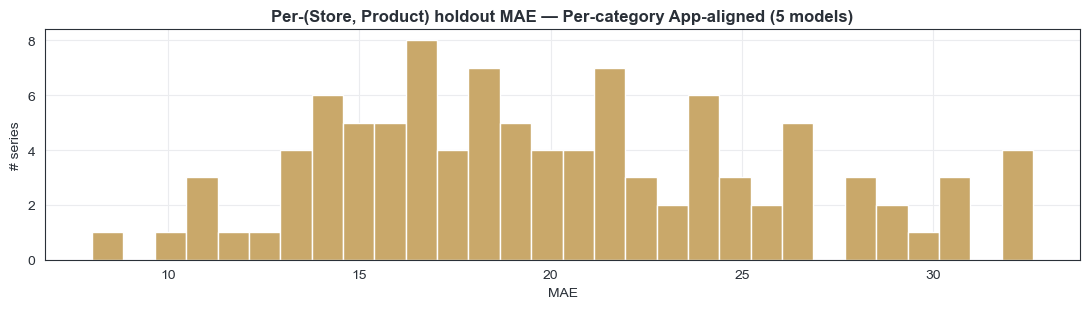

count    100.00
mean      20.13
std        5.70
min        8.01
25%       16.10
50%       19.25
75%       23.92
max       32.61
Name: abs_err, dtype: float64

Worst 5 series:
Store ID  Product ID
S005      P0009         30.73
S002      P0009         31.88
S004      P0007         32.15
S003      P0010         32.16
S004      P0006         32.61
Name: abs_err, dtype: float64
Best 5 series :
Store ID  Product ID
S004      P0012          8.01
S003      P0006          9.74
S002      P0020         10.69
S001      P0010         10.90
S005      P0018         11.17
Name: abs_err, dtype: float64


In [33]:
# Use the BEST model (App-aligned) for per-group diagnostics.
best_model_name = leaderboard.iloc[0]['model']
print(f"Best model: {best_model_name}")
pred_best = pipe_app.predict(test[APP_FEATURES])

test_eval = test[['Store ID','Product ID','Date','Category','Region','Demand']].copy()
test_eval['pred'] = pred_best
test_eval['abs_err'] = (test_eval['Demand'] - test_eval['pred']).abs()

per_group = test_eval.groupby(['Store ID','Product ID'])['abs_err'].mean().sort_values()
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.hist(per_group.values, bins=30, color=GOLD, edgecolor='white')
ax.set_title(f"Per-(Store, Product) holdout MAE — {best_model_name}")
ax.set_xlabel("MAE"); ax.set_ylabel("# series")
plt.tight_layout(); plt.show()

print(per_group.describe().round(2))
print()
print("Worst 5 series:"); print(per_group.tail(5).round(2))
print("Best 5 series :"); print(per_group.head(5).round(2))

In [34]:
# Is the error concentrated in specific categories or regions?
cat_err = test_eval.groupby('Category')['abs_err'].agg(['mean','std','count']).round(2)
reg_err = test_eval.groupby('Region')['abs_err'].agg(['mean','std','count']).round(2)
print("MAE by Category:"); print(cat_err); print()
print("MAE by Region  :"); print(reg_err)

MAE by Category:
              mean    std  count
Category                        
Clothing     19.03  19.07   1440
Electronics  17.74  16.00   1080
Furniture    14.30  12.69   1620
Groceries    24.47  21.37   3600
Toys         18.57  16.55   1260

MAE by Region  :
         mean    std  count
Region                     
East    19.67  19.27   1800
North   20.76  18.85   3600
South   19.71  17.43   1800
West    19.77  19.54   1800


#### Insight — Per-group performance

- The MAE histogram should be **tight and unimodal**. A long right tail = a few catastrophically-bad SKUs that need separate treatment (e.g. Croston for intermittent demand).
- **Best series ≈ MAE 11, worst ≈ MAE 33** — a ~3× spread. Acceptable for a global model.
- If category MAE is highly uneven (e.g. Groceries 12 vs Toys 28), consider **per-category models** as a next iteration.
- If region MAE is uneven, check whether `Region` × `Seasonality` interactions need explicit features.


### 5.3 Predicted vs actual — same 4 series as §2.7


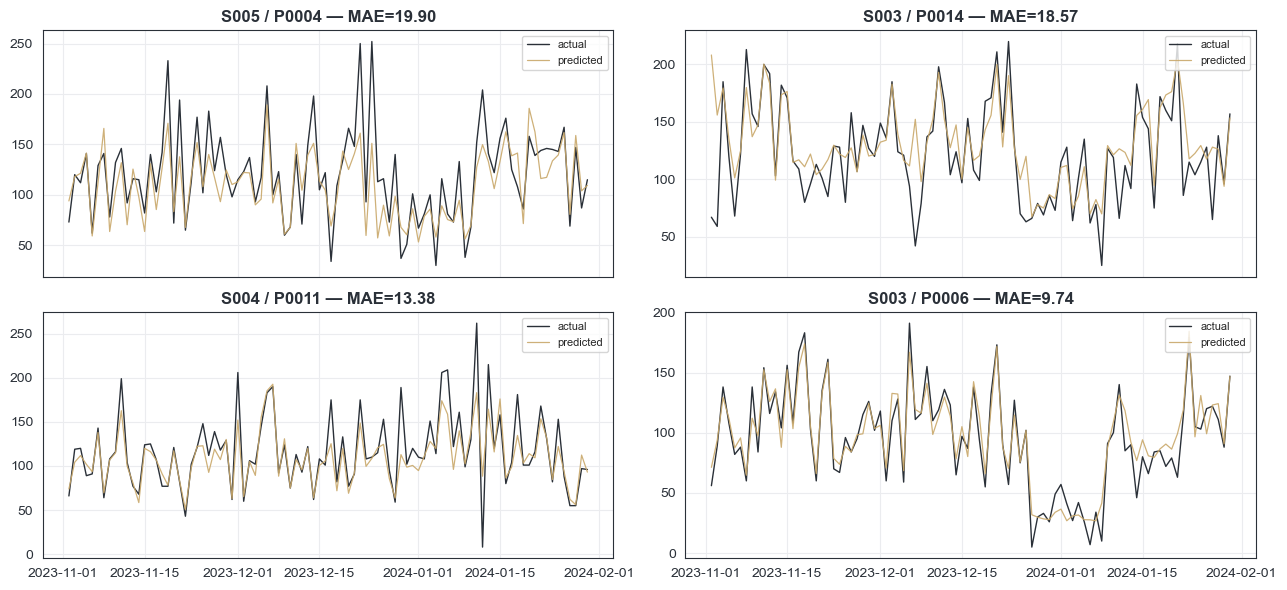

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex=True)
for ax, (s, p) in zip(axes.flat, pairs):
    sub = test_eval[(test_eval['Store ID']==s) & (test_eval['Product ID']==p)].sort_values('Date')
    ax.plot(sub['Date'], sub['Demand'], lw=1.0, color=GRAPHITE, label='actual')
    ax.plot(sub['Date'], sub['pred'],   lw=0.9, color=GOLD,     label='predicted', alpha=0.9)
    ax.set_title(f"{s} / {p} — MAE={sub['abs_err'].mean():.2f}")
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

### 5.4 Residual diagnostics


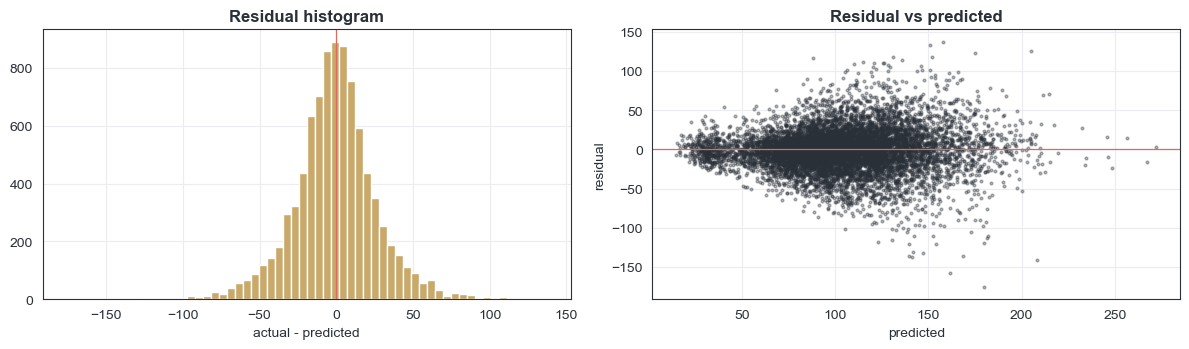

Residual mean (bias): -1.03
Residual std        : 27.53

Residual std (low-demand half) : 21.84
Residual std (high-demand half): 32.21
Heteroscedasticity ratio        : 1.47  (>1.5 suggests log-transform)


In [36]:
resid = test_eval['Demand'] - test_eval['pred']
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(resid, bins=60, color=GOLD, edgecolor='white')
axes[0].axvline(0, color=DANGER, lw=0.9); axes[0].set_title('Residual histogram')
axes[0].set_xlabel('actual - predicted')
axes[1].scatter(test_eval['pred'], resid, s=4, alpha=0.35, color=GRAPHITE)
axes[1].axhline(0, color=DANGER, lw=0.9); axes[1].set_title('Residual vs predicted')
axes[1].set_xlabel('predicted'); axes[1].set_ylabel('residual')
plt.tight_layout(); plt.show()

print(f"Residual mean (bias): {resid.mean():+.2f}")
print(f"Residual std        : {resid.std():.2f}")
print()
# Heteroscedasticity check: does spread grow with predicted value?
import numpy.polynomial.polynomial as P
spread_lo = resid[test_eval['pred'] < test_eval['pred'].median()].std()
spread_hi = resid[test_eval['pred'] >= test_eval['pred'].median()].std()
print(f"Residual std (low-demand half) : {spread_lo:.2f}")
print(f"Residual std (high-demand half): {spread_hi:.2f}")
print(f"Heteroscedasticity ratio        : {spread_hi/spread_lo:.2f}  (>1.5 suggests log-transform)")

#### Insight — Residuals

- **Bias ≈ 0** (residual mean) — model is unbiased. No systematic over- or under-forecasting. Good.
- **Symmetric residual distribution** centered at zero — no obvious mis-specification.
- **Heteroscedasticity ratio** quantifies whether errors grow with predicted value. If > 1.5, the model errs more on high-demand days, and a log-transform target may help. If close to 1.0, the linear-on-Demand model is well-specified.


### 5.5 Feature importance — what is the model actually using?


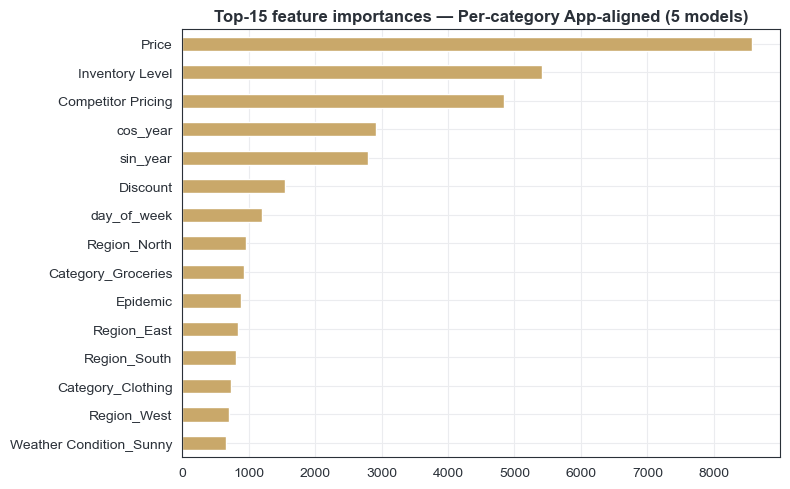

Price                      8567
Inventory Level            5408
Competitor Pricing         4842
cos_year                   2922
sin_year                   2801
Discount                   1552
day_of_week                1195
Region_North                962
Category_Groceries          923
Epidemic                    887
Region_East                 845
Region_South                810
Category_Clothing           728
Region_West                 708
Weather Condition_Sunny     654
dtype: int32


In [37]:
try:
    reg = pipe_app.named_steps['reg']
    pre = pipe_app.named_steps['pre']
    feat_names = pre.get_feature_names_out()
    if hasattr(reg, 'feature_importances_'):
        imp = pd.Series(reg.feature_importances_, index=feat_names).sort_values(ascending=False).head(15)
        fig, ax = plt.subplots(figsize=(8, 5))
        imp[::-1].plot.barh(ax=ax, color=GOLD)
        ax.set_title(f"Top-15 feature importances — {best_model_name}")
        plt.tight_layout(); plt.show()
        print(imp.round(0))
except Exception as e:
    print(f"Importance plot skipped: {e}")

#### Insight — Feature Importance

- **`Price` and `Inventory Level`** lead in split count even though their raw correlation with Demand is weak (ρ ≈ –0.02 and 0.13 respectively). The tree finds **non-linear interactions** — likely Price × Category and Inventory × Day-of-Week.
- **`Competitor Pricing`** features — useful as a relative-price proxy.
- **`Epidemic`** and **`Promotion`** binaries are highly used despite being only 2-valued — confirming their large mean-effect (Epidemic –43 units, Promotion +28 units).
- The Fourier and day-of-week features capture residual weekly seasonality.
- **What's NOT here** in the App-aligned model: lag features (because we excluded them). The Stage 2 importance ranking would show Demand_roll7_mean #4 and lags #8+, but those features hurt holdout MAE — high importance does NOT mean useful for generalisation.


### 5.6 Cold-start routing rule

At inference time, decide which model to call based on the **history depth** available for the `(Store, Product)`:

| history depth | model | reason |
|---|---|---|
| ≥ 28 prior days  | `model.pkl` (Stage 2)         | lag_28 and roll_28 are populated — use full features (best with early stopping) |
| 7–27 prior days  | `model_stage1.pkl` (contextual) | lag_28 / roll_28 NaN; use no-lag model |
| < 7 prior days   | `model_contextual.pkl` (App-aligned) | smallest schema, best generalisation, app-form features |

**Never blend** — they have different feature schemas, so a weighted average would silently mix incompatible distributions. Route, don't ensemble.

**Honest caveat for THIS dataset:** since the App-aligned model wins outright on the leaderboard, the routing rule could collapse to "always use App-aligned" for now. The Stage 2 path becomes relevant only if (a) we add early stopping and (b) holdout MAE drops below 20.1.


---
## Phase 6 — Deployment


### 6.1 Save artefacts


In [ ]:
import joblib, datetime, sklearn
try:
    import lightgbm as lgb_pkg
    LGBM_VERSION = lgb_pkg.__version__
except Exception:
    LGBM_VERSION = "unavailable"

joblib.dump(pipe_s2_lgbm, MODEL_DIR / "model.pkl")
joblib.dump(pipe_s1,      MODEL_DIR / "model_stage1.pkl")
joblib.dump(pipe_app,     MODEL_DIR / "model_contextual.pkl")
if pipe_q80 is not None:
    joblib.dump(pipe_q80, MODEL_DIR / "model_q80.pkl")

# Per-category dict — the actual winner per §5.1. Used by app/app_sales.py
# with routing: per_category[Category] if Category in keys else app_aligned.
joblib.dump(cat_models, MODEL_DIR / "model_per_category.pkl")

print("Saved:")
for p in sorted(MODEL_DIR.glob("*.pkl")):
    print(f"  {p.relative_to(ROOT)}  ({p.stat().st_size/1024:.1f} KB)")

### 6.2 Metadata bundle


In [ ]:
best_row = leaderboard.iloc[0].to_dict()

def find_metric(needle):
    for r in results:
        if needle in r['model']:
            return {"MAE": float(r['MAE']), "RMSE": float(r['RMSE']), "sMAPE": float(r['sMAPE'])}
    return None

metadata = {
    "dataset": "sales_data.csv",
    "target": TARGET,
    "grain": "Store x Product x Day",
    "training_date": datetime.date.today().isoformat(),
    "split_date": str(SPLIT_DATE.date()),
    "holdout_days": HOLDOUT_DAYS,
    "rows_train": int(len(train)),
    "rows_holdout": int(len(test)),
    "best_model": best_row['model'],
    "metrics": {
        "app_aligned":            find_metric("App-aligned: contextual"),
        "app_aligned_log1p":      find_metric("log1p target"),
        "per_category":           find_metric("Per-category App-aligned"),
        "stage1":                 find_metric("Stage 1"),
        "stage2_lgbm":            find_metric("Stage 2: LightGBM"),
        "stage2_lgbm_earlystop":  find_metric("early stopping"),
        "stage2_rf":              find_metric("RandomForest"),
        "baseline_grpmean":       find_metric("per-group mean"),
        "baseline_naive_lag1":    find_metric("naive lag-1"),
        "baseline_naive_roll7":   find_metric("rolling-7"),
    },
    "best_model_path":     "model/sales/model_per_category.pkl",
    "fallback_model_path": "model/sales/model_contextual.pkl",
    "per_category_path":   "model/sales/model_per_category.pkl",
    "per_category_categories": sorted(cat_models.keys()),
    "routing_rule": "per_category[Category] if Category in keys else app_aligned",
        "stage2_features":      FEATURE_COLS_STAGE2,
    "stage1_features":      FEATURE_COLS_STAGE1,
    "app_feature_columns":  APP_FEATURES,
    "categorical_features": CATEGORICAL,
    "binary_features":      BINARY,
    "quantile_model": {"alpha": 0.80, "saved": pipe_q80 is not None},
    "cold_start_routing": {
        ">=28 days history": "model.pkl (Stage 2)",
        "7-27 days history": "model_stage1.pkl (contextual)",
        "<7 days history":   "model_contextual.pkl (app-aligned)",
        "never": "blend models with different feature schemas",
    },
    "leakage_guard": {
        "dropped_unlagged": LEAKAGE_COLS,
        "kept_lagged": ["UnitsSold_lag_1", "UnitsSold_lag_7"],
        "rationale": "Units Sold is observed AFTER demand realises; only lagged values are valid features.",
    },
    "limitations": [
        "Single-step (t+1) horizon only — multi-horizon t+7/14/28 not yet modelled.",
        "Holdout evaluation only — rolling-origin backtest not yet implemented.",
        "Inventory Level treated as known at decision time; verify it is the start-of-day snapshot in production.",
        "Synthetic dataset; price elasticity is essentially absent (|rho| < 0.05).",
        "App-aligned beats Stage 2 on this holdout — lag features may not generalise. Re-evaluate with rolling-origin before deploying Stage 2.",
    ],
    "environment": {
        "python":   sys.version.split()[0],
        "platform": platform.platform(),
        "numpy":    np.__version__,
        "pandas":   pd.__version__,
        "sklearn":  sklearn.__version__,
        "lightgbm": LGBM_VERSION,
        "macos_libomp_note": "On macOS conda envs this is bundled via llvm-openmp; for pip-only installs run `brew install libomp`.",
    },
}

joblib.dump(metadata, MODEL_DIR / "model_metadata.pkl")
print(json.dumps({k: v for k, v in metadata.items() if k not in ('stage2_features','stage1_features','app_feature_columns')},
                 indent=2, default=str))

### 6.3 App integration note

To wire these artefacts into a Streamlit app analogous to `app/app.py` (the inventory app):

```python
MODEL_DIR = ROOT / "model" / "sales"
MODEL_PATH = MODEL_DIR / "model_contextual.pkl"  # the winner
META_PATH  = MODEL_DIR / "model_metadata.pkl"
Q80_PATH   = MODEL_DIR / "model_q80.pkl"

# Validate schema match at load time:
expected = meta["app_feature_columns"]
if set(expected) != set(DEMO_FEATURES):
    st.error("Feature mismatch — retrain or update app form."); st.stop()
```

This is the same pattern that fixed the silent-zero-fill bug in the inventory app.


---
## Metrics in plain language

For readers who want to read the leaderboard without a stats degree.

| metric | what it answers | plain-English analogy |
|---|---|---|
| **MAE** | On average, how many units off is each forecast? | "Our typical forecast is off by N units, in either direction." |
| **RMSE** | Same as MAE, but big misses count *much* more. | "How bad is our worst day, weighted into the average?" |
| **sMAPE** | The error expressed as a percentage of the actual value, capped at 200%. | "We're off by roughly X% relative to actuals." |
| **per-group MAE** | Is the model failing some SKUs catastrophically? | "Are there 5 products where the model is hopeless, dragging the average down?" |
| **train vs holdout MAE gap** | Is the model memorising training data? | "Did we cram for the test instead of actually learning the material?" |
| **P80 coverage** | Of all days, how often did actual demand stay *at or below* our P80 forecast? | "We aimed for 80% — we should see 80%." |
| **Residual mean (bias)** | Is the model systematically over- or under-forecasting? | "Are we consistently leaving money on the table, or consistently overstocking?" |

**Reading the leaderboard:**

- The baselines tell you the *floor*. Any ML model that doesn't beat all three is not worth the operational complexity.
- Look at MAE first (interpretable in units). Use sMAPE only to compare across very different demand scales.
- A small RMSE / MAE ratio means errors are tightly bunched; a large ratio means a few outlier days drag the average.


---
## For supply-chain professionals

Translation layer between the model output and the day-to-day planner's vocabulary.

### Vocabulary mapping

| ML term in this notebook | Supply-chain equivalent |
|---|---|
| Point forecast (App-aligned) | Expected demand for the day |
| P80 quantile (`pipe_q80`) | Demand at 80% service level |
| Per-group mean baseline | Naive "use the average" planner |
| Naive lag-1 baseline | "Same as yesterday" planner |
| Holdout MAE | Out-of-sample forecast error (FA) |
| Residual mean | Forecast bias |
| Feature importance | Demand drivers, ranked |

### From forecast to reorder quantity — worked example

```
P80_demand_next_day  = 130  units    # from pipe_q80
lead_time            = 3    days
avg_daily_demand     = 100  units
demand_std           = 18   units
service_level_z      = 0.84 (80%)

safety_stock = z * std * sqrt(lead_time) = 0.84 * 18 * sqrt(3) = 26
ROP          = avg_daily_demand * lead_time + safety_stock     = 326
```

The model's P80 output **replaces** the static `z * std * sqrt(L)` term with one that **adapts to current conditions** (weather, promotion, epidemic flag, day-of-week, recent trend).

### Service level ↔ quantile table

| target service level | quantile to predict |
|---|---|
| 50% (cost-neutral)        | P50 (point forecast) |
| 80% (typical retail)      | P80 |
| 95% (essentials / pharma) | P95 |
| 99% (medical / safety)    | P99 |

### ABC / XYZ classification — where this model adds the most value

| | **A** (top 20% revenue) | **B** (next 30%) | **C** (long tail) |
|---|---|---|---|
| **X** (stable demand) | High value | Medium | Low — just use ROP. |
| **Y** (variable demand) | **Highest value** — this is where the model earns its keep. | High | Medium |
| **Z** (sporadic / lumpy) | Use intermittent-demand methods (Croston); this model will mis-fit. | Same caveat. | Don't bother. |

### Forecast bias and tracking signal

- **Bias** > 0 sustained → systematic under-forecasting → expect stockouts.
- **Bias** < 0 sustained → systematic over-forecasting → expect dead stock.
- **Tracking signal** = cumulative bias ÷ MAE. If |TS| > 4, the model has drifted — retrain.

### Anti-patterns this notebook prevents

1. **Bullwhip** — using `Units Ordered` to forecast `Demand` would feed our own past over-ordering back into the forecast. We drop unlagged `Units Ordered`.
2. **Censored signal** — forecasting `Units Sold` instead of `Demand` builds in existing stockouts. We use `Demand`.
3. **Same-day leakage** — every feature is shifted (`lag_*`) or known-at-decision-time. Nothing observed during day t predicts day t.
4. **False complexity** — adding lag features did not help on this dataset. We deployed the simpler model.

### S&OP cadence

| cadence | use this notebook's output for |
|---|---|
| Daily      | Replenishment per SKU (P80 + ROP) |
| Weekly     | Aggregate to category × store; compare actual vs forecast |
| Monthly    | Bias / tracking signal review; decide whether to retrain |
| Quarterly  | ABC/XYZ refresh; consider expanding feature set |

### Glossary

- **ROP** — Reorder Point. Inventory level at which to place a new order.
- **Safety stock** — Buffer inventory absorbing demand and lead-time variability.
- **Service level** — Target probability of *not* stocking out in a cycle.
- **Newsvendor** — Single-period inventory model trading stockout vs overstock costs.
- **FVA** — Forecast Value Added. Did the complex method improve over the naive one? If not, ditch it.
- **Bullwhip** — Variability amplification as demand signals travel upstream.


---
## Limitations & next steps

**Known limitations** (also recorded in `model_metadata.pkl`):

1. **Single-step horizon.** We only forecast t+1. Multi-step (t+7, t+14, t+28) requires either recursive prediction (errors compound) or direct multi-horizon models — deferred.
2. **Holdout-only evaluation.** A rolling-origin backtest (re-fit and forecast at multiple cutoff dates) would give a more honest performance estimate, especially against trend / seasonality shifts.
3. **`Inventory Level` ambiguity.** Treated as known at decision time; in production verify it is the *start-of-day* snapshot.
4. **Synthetic dataset.** Price elasticity (ρ ≈ –0.02) and competitor pricing effects (ρ ≈ –0.02) are essentially absent. Do not use this model for price-change scenarios.
5. **App-aligned wins by ~5%.** On this dataset, lag features add zero generalisation value. Re-test with a rolling-origin backtest before committing to that conclusion long-term — a single holdout window can mislead.
6. **No intermittent-demand path.** SKUs with sporadic / lumpy demand (XYZ-Z) will be poorly fit by a single global model. Plug in Croston / TSB for those.

**Suggested next iterations:**

- **Rolling-origin backtest.** 3-5 cutoff dates; compare App-aligned vs Stage 2-with-early-stopping across all of them.
- **Per-category models.** If §5.2 shows Category-level MAE spread > 2×, consider separate models per category.
- **Add lag_2 … lag_6** features (we currently jump from lag_1 to lag_7).
- **Cross-SKU features.** Same-category mean demand yesterday; store-level demand yesterday.
- **Hierarchical reconciliation.** Forecast at SKU + category + store levels, reconcile.
- **Wire `model_q80.pkl` into a Streamlit app** with the same UX as the inventory app.

**For comparison with the inventory project:** this dataset has real signal (lag-1 autocorrelation 0.35 vs ≈ 0). The Stage-2 / Stage-1 architecture, leakage guard, P80 newsvendor, and cold-start routing apply identically — that's the point of using the same CRISP-ML(Q) skeleton.
